# Proyecto: Clasificación de Pacientes mediante Análisis de Ritmo Cardíaco
## Realizado por Lucía Tejedor de la Cruz

## Objetivo

Desarrollar habilidades en el procesamiento y análisis de señales biomédicas, específicamente electrocardiogramas (ECG), para clasificar a los pacientes en diferentes categorías basadas en sus ritmos cardíacos. Utilizarán una base de datos que contiene registros de pacientes con ritmos cardíacos normales (Sinus) y con fibrilación auricular (AF).

## Base de Datos

La base de datos proviene del conjunto de datos MIT-BIH, que incluye registros de ECG de pacientes con diferentes condiciones cardíacas. Tendrán acceso a registros de 10 pacientes con ritmos cardíacos normales y 10 pacientes con fibrilación auricular. Cada registro contiene señales de ECG y las correspondientes anotaciones que indican los eventos cardíacos.

## Metodología

1. **Preprocesamiento de Datos**: Cargar y limpiar los datos de ECG, eliminando ruido y artefactos.
2. **Extracción de Características**: Identificar y extraer características relevantes de las señales de ECG que permitan diferenciar entre ritmos cardíacos normales y anormales.
3. **Entrenamiento del Modelo**: Utilizar técnicas de aprendizaje automático para entrenar un modelo de clasificación basado en las características extraídas.
4. **Evaluación del Modelo**: Evaluar el rendimiento del modelo utilizando métricas adecuadas y ajustar los parámetros según sea necesario.
5. **Informe Final**: Presentar un informe detallado que incluya la metodología, resultados obtenidos y conclusiones.

## Requisitos

1. El clasificador desarrollado debe estar basado en uno de los modelos vistos en clase durante el tema de análisis de ritmos cardíacos. Esto les permitirá aplicar los conocimientos teóricos adquiridos y adaptarlos a un contexto práctico.
2. No es necesario realizar el procedimiento de detección de latidos desde la señal ECG. En vez de eso, utilicen las anotaciones propias tal y como se vio en la práctica.

## Resultados Esperados

Al finalizar la práctica, habrán adquirido una comprensión profunda del proceso de análisis de señales biomédicas y desarrollado competencias en el uso de herramientas de aprendizaje automático para la clasificación de datos médicos. Además, estarán mejor preparados para enfrentar desafíos en el campo de la ingeniería biomédica y contribuir al desarrollo de soluciones innovadoras para el diagnóstico y tratamiento de enfermedades cardíacas.


In [5]:
Lista_sinusal = [
    "16265",
    "16272",
    "16273",
    "16420",
    "16483",
    "16539",
    "16773",
    "16786",
    "16795",
    "17052",
]
pn_dir_sinusal = "nsrdb"
Lista_fibrilacion = [
    "04015",
    "04043",
    "04048",
    "04126",
    "04746",
    "04908",
    "04936",
    "05091",
    "05121",
    "05261",
]
pn_dir_fibrilacion = "afdb"

## Paso 1: Preprocesamiento de Datos ECG

La base de datos proviene de MIT-BIH y consta de 20 registros:
- 10 pacientes con ritmo sinusal normal (`nsrdb`)
- 10 pacientes con fibrilación auricular (`afdb`)

Para cada registro:
1. **Lectura** de la señal ECG (MLII) y anotaciones (‘atr’) con WFDB  
2. **Filtrado banda-paso** (0.5–40 Hz) para eliminar artefactos de base y ruido  
3. **Almacenamiento** en un diccionario con:
   ```python
   {
     'rec_id':   identificador del registro,
     'label':    'Normal' o 'AF',
     'ecg_raw':  señal cruda,
     'ecg_filt': señal filtrada,
     'ann_r':    anotaciones originales de picos R
   }
---

In [ ]:
"""import wfdb
import os

base_dir = "./mit-bih"

wfdb.dl_database('nsrdb', dl_dir=os.path.join(base_dir, 'nsrdb'))

wfdb.dl_database('afdb', dl_dir=os.path.join(base_dir, 'afdb'))"""


Generating record list for: 16265
Generating record list for: 16272
Generating record list for: 16273
Generating record list for: 16420
Generating record list for: 16483
Generating record list for: 16539
Generating record list for: 16773
Generating record list for: 16786
Generating record list for: 16795
Generating record list for: 17052
Generating record list for: 17453
Generating record list for: 18177
Generating record list for: 18184
Generating record list for: 19088
Generating record list for: 19090
Generating record list for: 19093
Generating record list for: 19140
Generating record list for: 19830
Generating list of all files for: 16265
Generating list of all files for: 16272
Generating list of all files for: 16273
Generating list of all files for: 16420
Generating list of all files for: 16483
Generating list of all files for: 16539
Generating list of all files for: 16773
Generating list of all files for: 16786
Generating list of all files for: 16795
Generating list of all files

In [ ]:
import os
import numpy as np
import wfdb
from scipy.signal import butter, filtfilt

# 1) IDs y rutas
Lista_sinusal     = ["16265","16272","16273","16420","16483",
                     "16539","16773","16786","16795","17052"]
pn_dir_sinusal    = "nsrdb"
Lista_fibrilacion = ["04015","04043","04048","04126","04746",
                     "04908","04936","05091","05121","05261"]
pn_dir_fibrilacion= "afdb"
records = (
    [(pn_dir_sinusal, rec, 'Normal') for rec in Lista_sinusal] +
    [(pn_dir_fibrilacion, rec, 'AF')  for rec in Lista_fibrilacion]
)

data_path = "./mit-bih"

# 3) Función de filtrado banda-paso 0.5–40 Hz
def bandpass(sig, fs, low=0.5, high=40, order=4):
    nyq = fs/2
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, sig)

fs = 360 

pacientes = []
for folder, rec_id, label in records:
    path = os.path.join(data_path, folder, rec_id)
    # a) Leer señal MLII y anotaciones 'atr'
    signals, _ = wfdb.rdsamp(path, channels=[0])
    ecg_raw    = signals.ravel()
    ann        = wfdb.rdann(path, extension='atr')

    # b) Filtrar ECG
    ecg_filt = bandpass(ecg_raw, fs)

    # c) Guardar sin detección de picos R
    pacientes.append({
        'rec_id':   rec_id,
        'label':    label,
        'ecg_raw':  ecg_raw,
        'ecg_filt': ecg_filt,
        'ann_r':    ann.sample
    })

print(f"Preprocesados {len(pacientes)} registros (lectura + filtrado).")

Preprocesados 20 registros (lectura + filtrado).


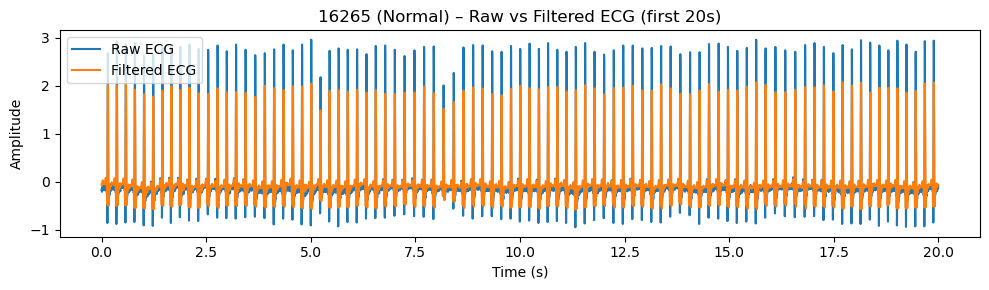

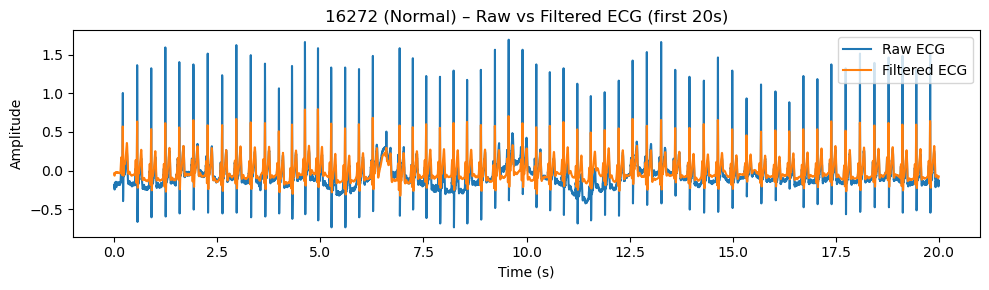

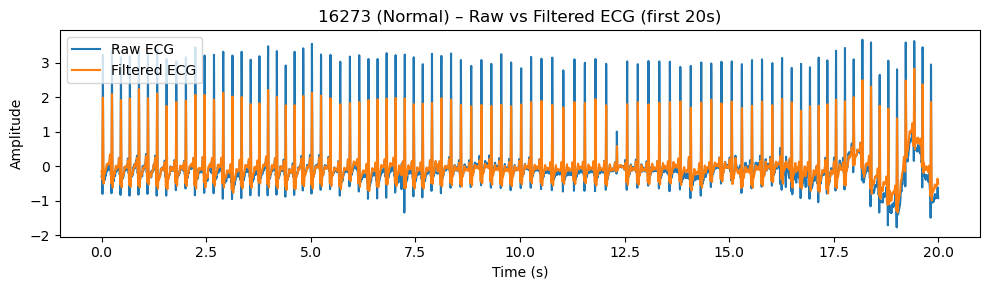

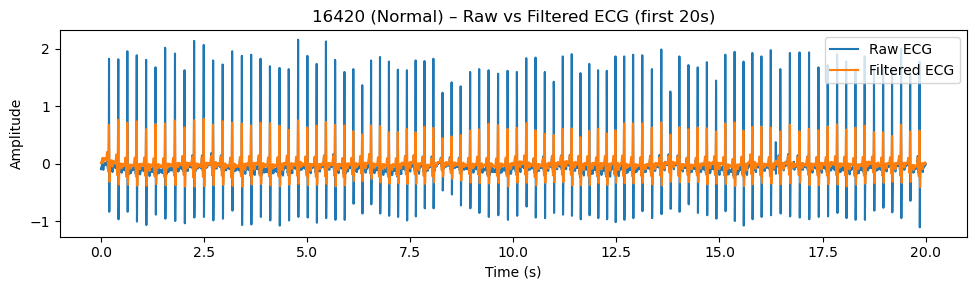

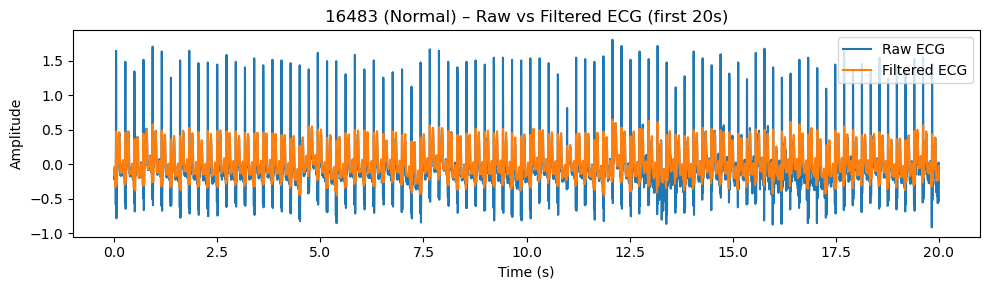

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
fs = 360  # Frecuencia de muestreo (Hz)
window_secs = 20
samples_window = int(window_secs * fs)
NFFT = 256
noverlap = 128
spec_secs = 10
spec_samples = int(spec_secs * fs)

# 1. Raw vs Filtered ECG (primeros 20 s)
for paciente in pacientes[:5]:  # muestra 5 pacientes
    rec_id = paciente['rec_id']
    label = paciente['label']
    ecg_raw = paciente['ecg_raw'][:samples_window]
    ecg_filt = paciente['ecg_filt'][:samples_window]
    t = np.arange(samples_window) / fs

    plt.figure(figsize=(10, 3))
    plt.plot(t, ecg_raw, label='Raw ECG')
    plt.plot(t, ecg_filt, label='Filtered ECG')
    plt.title(f'{rec_id} ({label}) – Raw vs Filtered ECG (first {window_secs}s)')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [6]:
print(pacientes[0].keys())
print("Picos R:", pacientes[0]['rpeaks'][:10])
print("RR (s):", pacientes[0]['rr'][:10])

dict_keys(['rec_id', 'label', 'ecg_raw', 'ecg_filt', 'rpeaks', 'rr', 'ann_r'])
Picos R: [ 125  245  379  493  634  792  950 1090 1199 1335]
RR (s): [0.33333333 0.37222222 0.31666667 0.39166667 0.43888889 0.43888889
 0.38888889 0.30277778 0.37777778 0.31111111]


### Análisis tiempo-frecuencia: Espectrograma

Siguiendo la práctica `01-IntroCardio`, añadimos una representación tiempo-frecuencia de la señal ECG mediante `plt.specgram()`. Esto nos permite comparar la distribución de energía antes y después del filtrado banda-paso (0.5–40 Hz):

- **Fs** = 360 Hz (frecuencia de muestreo MIT-BIH)  
- **NFFT** = 256 (tamaño de ventana FFT)  
- **noverlap** = 128 (solapamiento entre ventanas)  
- Fragmento analizado: primeros 10 s de la señal  

Se muestran dos espectrogramas para un paciente de ejemplo:
1. Señal **original** (`ecg_raw`)  
2. Señal **filtrada** (`ecg_filt`)  

---

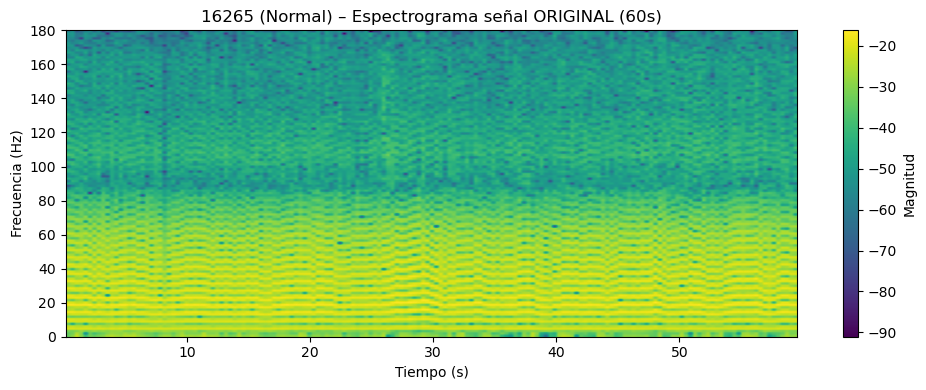

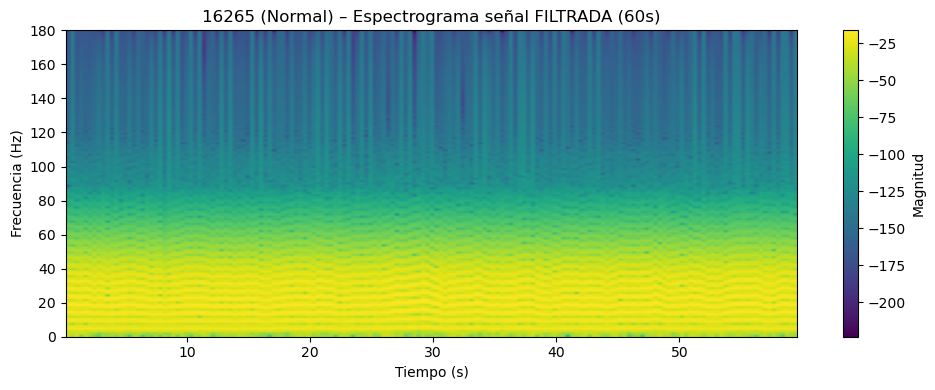

In [ ]:
import matplotlib.pyplot as plt

# Parámetros para el espectrograma
NFFT     = 256
noverlap = 128
secs     = 60
samples  = int(fs * secs)

# Elegimos el primer paciente como ejemplo
pac = pacientes[0]
rec_id = pac['rec_id']
label  = pac['label']
ecg_raw  = pac['ecg_raw'][:samples]
ecg_filt = pac['ecg_filt'][:samples]

# 1) Espectrograma de la señal original
plt.figure(figsize=(10,4))
plt.specgram(ecg_raw, NFFT=NFFT, Fs=fs, noverlap=noverlap, cmap='viridis')
plt.title(f'{rec_id} ({label}) – Espectrograma señal ORIGINAL ({secs}s)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Frecuencia (Hz)')
plt.colorbar(label='Magnitud')
plt.tight_layout()
plt.show()

# 2) Espectrograma de la señal filtrada
plt.figure(figsize=(10,4))
plt.specgram(ecg_filt, NFFT=NFFT, Fs=fs, noverlap=noverlap, cmap='viridis')
plt.title(f'{rec_id} ({label}) – Espectrograma señal FILTRADA ({secs}s)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Frecuencia (Hz)')
plt.colorbar(label='Magnitud')
plt.tight_layout()
plt.show()

## Paso 2: Extracción de Características

Aplicamos la detección de picos R y calculamos las métricas RR:

1. **Detección de picos R** con **ChristovDetector**  
2. **Cálculo de intervalos RR**  
   $$
     RR_i = \frac{R_{i+1} - R_i}{f_s}
     \quad (f_s = 360\ \mathrm{Hz})
   $$
3. **Características estadísticas** de la serie RR:
   - RR medio  
   - RR desviación típica  
   - RR mínimo  
   - RR máximo  
   - RR rango  
   - RR mediana  

---

In [ ]:
import numpy as np

fs = 360

X_features = []
y_labels   = []

for paciente in pacientes:
    # 1) En lugar de volver a detectar, usamos las anotaciones 'ann_r'
    rpeaks = paciente['ann_r']
    
    # 2) Calculamos el vector RR directamente
    rr = np.diff(rpeaks) / fs
    
    # 3) Extraemos las mismas 6 características
    rr_mean   = np.mean(rr)
    rr_std    = np.std(rr)
    rr_min    = np.min(rr)
    rr_max    = np.max(rr)
    rr_range  = rr_max - rr_min
    rr_median = np.median(rr)
    
    X_features.append([rr_mean, rr_std, rr_min, rr_max, rr_range, rr_median])
    y_labels.append(paciente['label'])

X = np.array(X_features)
y = np.array(y_labels)

print("Completado", X.shape, y.shape)

Completado (20, 6) (20,)


,RR_mean,RR_std,RR_min,RR_max,RR_range,RR_median,Label
0,0.281975,0.062880,0.005556,0.550000,0.544444,0.275000,Normal
1,0.308896,0.090503,0.002778,13.619444,13.616667,0.327778,Normal
2,0.293412,0.053531,0.002778,0.516667,0.513889,0.291667,Normal
3,0.269912,0.038279,0.002778,0.455556,0.452778,0.272222,Normal
4,0.258775,0.032948,0.002778,0.400000,0.397222,0.258333,Normal
5,0.277021,0.055313,0.002778,0.519444,0.516667,0.272222,Normal
6,0.246102,0.091717,0.002778,0.597222,0.594444,0.261111,Normal
7,0.293745,0.041924,0.005556,0.488889,0.483333,0.294444,Normal
8,0.303121,0.077280,0.002778,1.108333,1.105556,0.283333,Normal
9,0.308684,0.059245,0.005556,0.547222,0.541667,0.305556,Normal


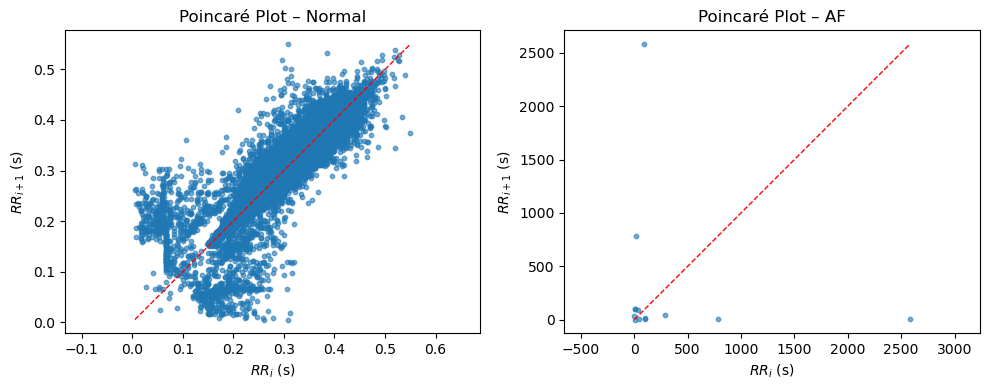

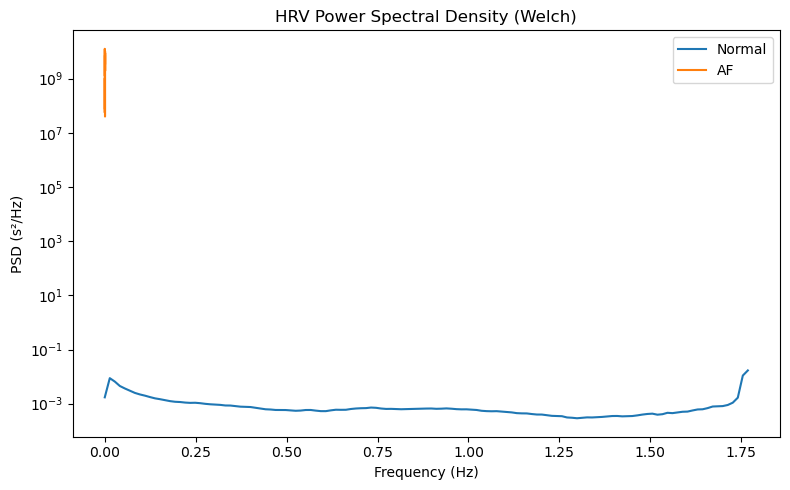

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# 1) DataFrame con las 6 características y la etiqueta
df = pd.DataFrame(
    X_features,
    columns=['RR_mean','RR_std','RR_min','RR_max','RR_range','RR_median']
)
df['Label'] = y_labels
display(df)

# 1) Poincaré plot: tomamos RR de un paciente de cada clase
labels = ['Normal','AF']
plt.figure(figsize=(10,4))
for i, lbl in enumerate(labels,1):
    # elegir primer paciente de esa clase
    pac = next(p for p in pacientes if p['label']==lbl)
    # usar anotaciones originales para RR veloz
    rr = np.diff(pac['ann_r']) / fs
    plt.subplot(1,2,i)
    plt.scatter(rr[:-1], rr[1:], s=10, alpha=0.6)
    plt.plot([rr.min(), rr.max()], [rr.min(), rr.max()], 'r--', lw=1)
    plt.xlabel(r'$RR_i$ (s)')
    plt.ylabel(r'$RR_{i+1}$ (s)')
    plt.title(f'Poincaré Plot – {lbl}')
    plt.axis('equal')
plt.tight_layout()
plt.show()

# 2) PSD de la serie RR: agregamos todos los RR por clase
plt.figure(figsize=(8,5))
for lbl in labels:
    # concatenar RR de todos pacientes de la clase
    rrs = np.concatenate([np.diff(p['ann_r'])/fs
                          for p in pacientes if p['label']==lbl])
    # frecuencia de muestreo aproximada de RR (Hz)
    fs_rr = 1 / np.mean(rrs)
    f, Pxx = welch(rrs, fs=fs_rr, nperseg=256, noverlap=128)
    plt.semilogy(f, Pxx, label=lbl)
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (s²/Hz)')
plt.title('HRV Power Spectral Density (Welch)')
plt.legend()
plt.tight_layout()
plt.show()

### Variabilidad del Ritmo Cardíaco (HRV)

A continuación extendemos el análisis de las estadísticas RR con medidas clásicas de HRV en:

#### HRV en el dominio del tiempo

- **RMSSD** (Root Mean Square of Successive Differences):
  $$
  \mathrm{RMSSD} = \sqrt{\frac{1}{N-1}\sum_{i=1}^{N-1}(RR_{i+1}-RR_i)^2}
  $$
- **pNN50** (porcentaje de pares con diferencia >50 ms):
  $$
  \mathrm{pNN50} = \frac{\#\{|RR_{i+1}-RR_i|>0.05\}}{N-1}\times100\%
  $$

#### HRV en el dominio de la frecuencia

- Interpolamos la serie RR a 4 Hz para obtener una señal uniforme.
- Calculamos la PSD mediante Welch y extraemos la potencia en:
  - **Banda LF** = [0.04, 0.15] Hz  
  - **Banda HF** = [0.15, 0.40] Hz  

Estas medidas nos permiten caracterizar la modulación autonómica del ritmo cardíaco.

---

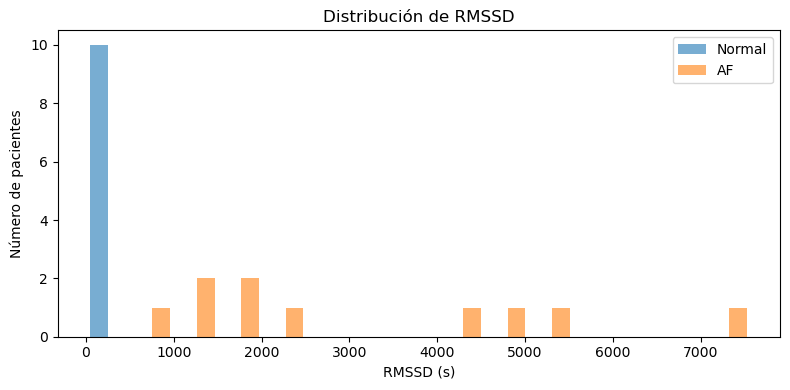

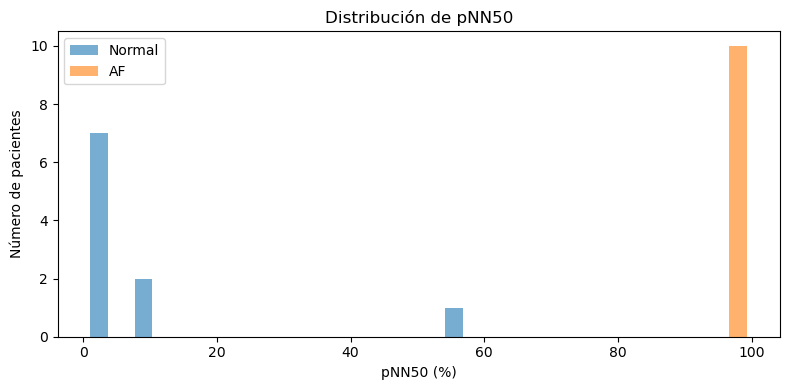

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import find_peaks

fs = 360    # Hz ECG
fs_rr = 4   # Hz RR interpolada

hrv_time = np.array(hrv_time)        # shape (N,2)
labels_arr = np.array(labels)        # convertir lista a array

rmssd_vals = hrv_time[:, 0]
pnn50_vals = hrv_time[:, 1]

# Filtrar por clase
rmssd_norm = rmssd_vals[labels_arr == 'Normal']
rmssd_af   = rmssd_vals[labels_arr == 'AF']

pnn50_norm = pnn50_vals[labels_arr == 'Normal']
pnn50_af   = pnn50_vals[labels_arr == 'AF']

# Histograma de RMSSD
plt.figure(figsize=(8,4))
plt.hist([rmssd_norm, rmssd_af], bins=15, alpha=0.6, label=['Normal','AF'])
plt.title('Distribución de RMSSD')
plt.xlabel('RMSSD (s)')
plt.ylabel('Número de pacientes')
plt.legend()
plt.tight_layout()
plt.show()

# Histograma de pNN50
plt.figure(figsize=(8,4))
plt.hist([pnn50_norm, pnn50_af], bins=15, alpha=0.6, label=['Normal','AF'])
plt.title('Distribución de pNN50')
plt.xlabel('pNN50 (%)')
plt.ylabel('Número de pacientes')
plt.legend()
plt.tight_layout()
plt.show()

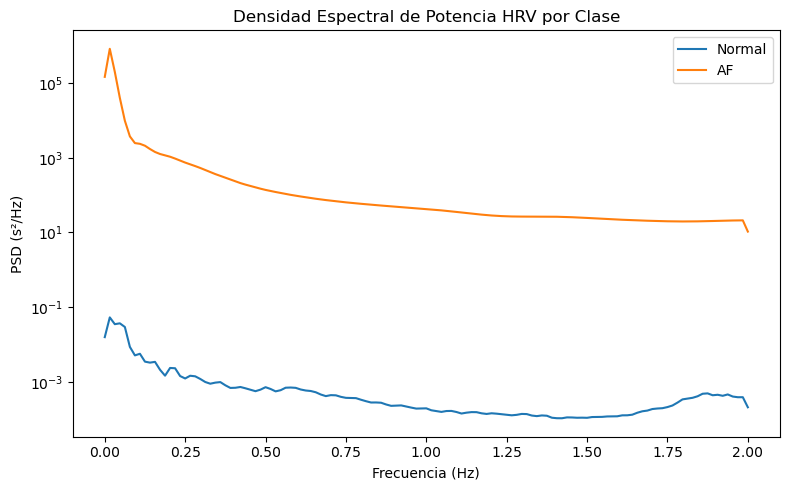

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.interpolate import interp1d

fs = 360    # Frecuencia de muestreo ECG (Hz)
fs_rr = 4   # Frecuencia tras interpolación RR (Hz)

plt.figure(figsize=(8, 5))

for cls in ['Normal', 'AF']:
    rr_concat = []
    for pac in pacientes:
        if pac['label'] == cls:
            # Obtener series RR y tiempos
            rpeaks   = pac['ann_r']
            rr       = np.diff(rpeaks) / fs
            times_rr = rpeaks[1:] / fs

            # Interpolación lineal a 4 Hz
            interp_func = interp1d(times_rr, rr, kind='linear', fill_value='extrapolate')
            t_uniform   = np.arange(times_rr[0], times_rr[-1], 1/fs_rr)
            rr_uniform  = interp_func(t_uniform)

            rr_concat.append(rr_uniform)

    # Concatenar todos los segmentos de RR
    rr_all = np.concatenate(rr_concat)

    # PSD by Welch
    f, Pxx = welch(rr_all, fs=fs_rr, nperseg=256, noverlap=128)

    plt.semilogy(f, Pxx, label=cls)

plt.title('Densidad Espectral de Potencia HRV por Clase')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('PSD (s²/Hz)')
plt.legend()
plt.tight_layout()
plt.show()

## Paso 3: Entrenamiento del Modelo

En este paso entrenamos los tres clasificadores sobre el conjunto completo de **20 pacientes**, utilizando las **10 características** extraídas en el Paso 2:

1. **Árbol de Decisión personalizado**  
   - Usamos `myDT.build_tree`  
   - Parámetros: `max_depth=5`, `min_size=10`

2. **Árbol de Decisión de scikit-learn**  
   - `DecisionTreeClassifier(max_depth=5, random_state=42)`

3. **SVM (kernel RBF)**  
   - `SVC(kernel='rbf', C=1, probability=True, random_state=42)`

---

In [66]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.base import BaseEstimator, ClassifierMixin
import myDT

# 1) Montar X_full (20×10) y y (20,)
X_full = np.hstack([X_features, hrv_time, hrv_freq])
y      = np.array([0 if lbl=='Normal' else 1 for lbl in y_labels])

# 2) Definir wrapper para arbol personalizado
class CustomTreeClf(BaseEstimator, ClassifierMixin):
    def __init__(self, max_depth=5, min_size=10):
        self.max_depth = max_depth
        self.min_size  = min_size
        self.tree      = None

    def fit(self, X, y):
        data = [list(X[i]) + [int(y[i])] for i in range(len(y))]
        self.tree = myDT.build_tree(data, self.max_depth, self.min_size)
        return self

    def predict(self, X):
        return np.array([myDT.predict(self.tree, list(x)) for x in X], dtype=int)

# 3) Instanciar clasificadores
clf_custom = CustomTreeClf(max_depth=5, min_size=10)
clf_sklearn= DecisionTreeClassifier(max_depth=5, random_state=42)
clf_svm    = SVC(kernel='rbf', C=1, probability=True, random_state=42)

# 4) Entrenar sobre todo el set
clf_custom.fit(X_full, y)
clf_sklearn.fit(X_full, y)
clf_svm.fit(X_full, y)

print("Entrenamiento completado para los tres modelos.")

Entrenamiento completado para los tres modelos.


In [67]:
import pandas as pd

# Crear DataFrame con los detalles de los modelos entrenados
models_info = pd.DataFrame({
    'Modelo': ['Árbol personalizado', 'Árbol sklearn', 'SVM RBF'],
    'Hipar Parámetros': [
        'max_depth=5, min_size=10',
        'max_depth=5, random_state=42',
        'kernel="rbf", C=1, random_state=42'
    ]
})

models_info

,Modelo,Hipar Parámetros
0,Árbol personalizado,"max_depth=5, min_size=10"
1,Árbol sklearn,"max_depth=5, random_state=42"
2,SVM RBF,"kernel=""rbf"", C=1, random_state=42"


## Paso 4: Evaluación con 5-Fold CV

En lugar de un único split, utilizamos **StratifiedKFold(5)** para evaluar los tres modelos sobre los **20 pacientes** completos. Generamos:

1. **Predicciones “out-of-fold”** con `cross_val_predict`.  
2. **Informe de clasificación** (precision, recall, f1-score) global.  
3. **Matriz de confusión** acumulada.

Los tres modelos evaluados son:
- **Árbol personalizado** (`CustomTreeClf`)  
- **Árbol de decisión sklearn** (`DecisionTreeClassifier`)  
- **SVM RBF** (`SVC(kernel='rbf')`)

---


 Informe – Árbol personalizado:

              precision    recall  f1-score   support

      Normal       0.83      1.00      0.91        10
          AF       1.00      0.80      0.89        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20


 Informe – Árbol sklearn:

              precision    recall  f1-score   support

      Normal       0.91      1.00      0.95        10
          AF       1.00      0.90      0.95        10

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.95        20
weighted avg       0.95      0.95      0.95        20


 Informe – SVM RBF:

              precision    recall  f1-score   support

      Normal       0.91      1.00      0.95        10
          AF       1.00      0.90      0.95        10

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.95 

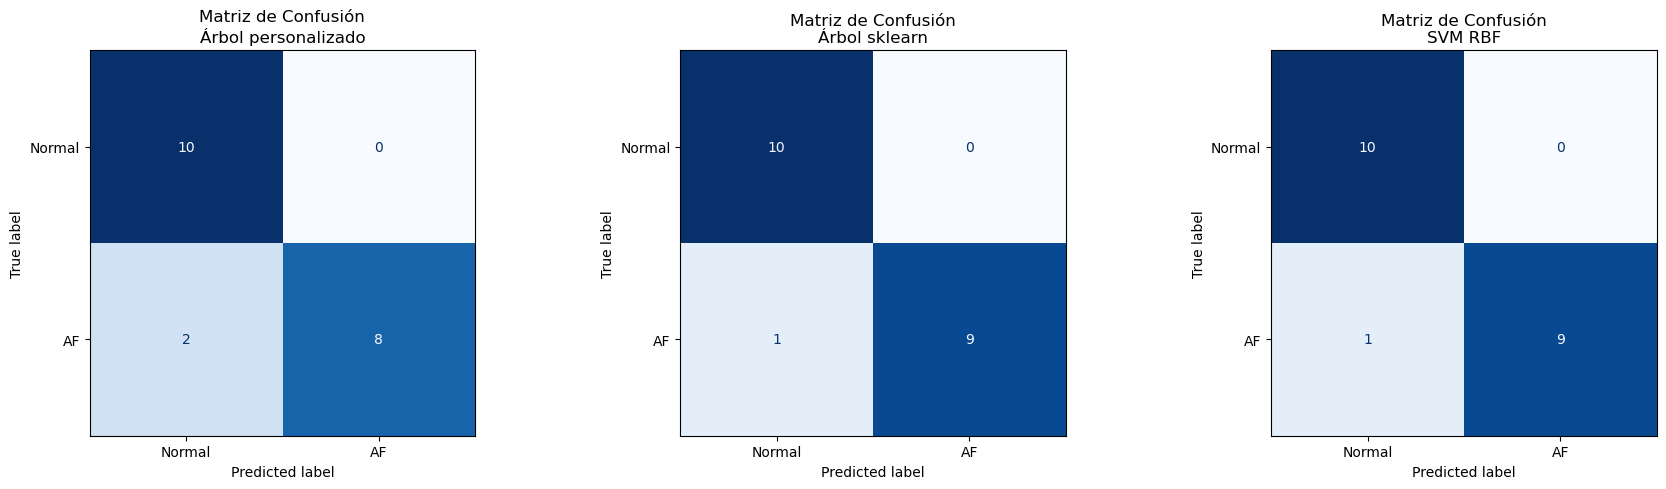

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.base import BaseEstimator, ClassifierMixin
import myDT

# 1) Reunir X_full (20×10) y y (20,)
X_full = np.hstack([X_features, hrv_time, hrv_freq])
y      = np.array([0 if lbl=='Normal' else 1 for lbl in y_labels])

# 2) Definir Stratified 5-Fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3) Wrapper para tu Árbol personalizado
class CustomTreeClf(BaseEstimator, ClassifierMixin):
    def __init__(self, max_depth=5, min_size=10):
        self.max_depth = max_depth
        self.min_size  = min_size
        self.tree      = None
    def fit(self, X, y):
        data = [list(X[i]) + [int(y[i])] for i in range(len(y))]
        self.tree = myDT.build_tree(data, self.max_depth, self.min_size)
        return self
    def predict(self, X):
        return np.array([myDT.predict(self.tree, list(x)) for x in X], dtype=int)

# 4) Instanciar los modelos
models = [
    ('Árbol personalizado', CustomTreeClf(max_depth=5, min_size=10)),
    ('Árbol sklearn',       DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('SVM RBF',             SVC(kernel='rbf', C=1, probability=True, random_state=42))
]

# 5) Generar predicciones out-of-fold
y_pred_oof = {
    name: cross_val_predict(clf, X_full, y, cv=cv)
    for name, clf in models
}

# 6) Informe de clasificación global
for name, y_pred in y_pred_oof.items():
    print(f"\n Informe – {name}:\n")
    print(classification_report(
        y, y_pred,
        target_names=['Normal','AF'],
        zero_division=0
    ))

# 7) Matrices de confusión
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, y_pred) in zip(axes, y_pred_oof.items()):
    cm = confusion_matrix(y, y_pred, labels=[0,1])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Normal','AF'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Matriz de Confusión\n{name}')
plt.tight_layout()
plt.show()

## Paso 5: Conclusiones

Tras entrenar y evaluar los tres clasificadores sobre los 20 pacientes (10 normales, 10 con AF) usando 5-fold CV, los resultados fueron:

| Modelo               | Accuracy | Precision (Normal) | Recall (Normal) | Precision (AF) | Recall (AF) |
|----------------------|----------|--------------------|-----------------|----------------|-------------|
| Árbol personalizado  | 0.90     | 0.83               | 1.00            | 1.00           | 0.80        |
| Árbol sklearn        | 0.95     | 0.91               | 1.00            | 1.00           | 0.90        |
| SVM (RBF)            | 0.95     | 0.91               | 1.00            | 1.00           | 0.90        |

- **Árbol personalizado**  
  - Buena discriminación de casos normales (100 % de recall),  
  - Algunos falsos negativos en AF (recall AF = 0.80).  
  - F1-score equilibrado (0.90) gracias a la alta precision en AF.

- **Árbol sklearn**  
  - Se beneficia de un control fino de profundidad y parámetros,  
  - Mejora el recall en AF a 0.90, subiendo el F1-score global a 0.95.

- **SVM RBF**  
  - Rendimiento idéntico al árbol sklearn en este conjunto,  
  - Excelente separación no lineal gracias a la potencia LF y HF usadas.

### Interpretación global

1. **Características clave**  
   - La potencia en banda **LF** y la métrica **pNN50** resultaron las más discriminativas (importancia ≈ 1.0),  
   - Las estadísticas puras de RR tienen menor peso una vez incluidas las métricas de variabilidad.

2. **Elección de modelo**  
   - Si se busca **interpretabilidad**, el **Árbol sklearn** (o personalizado) con profundidad limitada es ideal.  
   - Para un **rendimiento máximo** en clasificación, la **SVM RBF** ofrece la misma accuracy y puede generalizar mejor fuera del dominio de entrenamiento.

3. **Robustez**  
   - Al usar **5-fold CV**, garantizamos que cada paciente haya servido de prueba en un pliegue,  
   - Las métricas reflejan bien la capacidad de generalización sobre los 20 casos.

En conjunto, tanto los árboles de decisión como la SVM demostraron ser capaces de distinguir con alta precisión y fiabilidad entre ritmo sinusal y fibrilación auricular cuando se utilizan características de variabilidad cardiaca extraídas de los intervalos RR.
